<a href="https://colab.research.google.com/github/sudipta007modak/practicegit/blob/main/decisionTree1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_iris

In [7]:
iris_data = load_iris()


In [8]:
iris_df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
iris_df.columns = iris_df.columns.str.replace(' ', '_')
iris_df.columns = iris_df.columns.str.replace('_(cm)', '', regex=False)
iris_df[:5]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
iris_df['target'] = iris_data.target
iris_df.loc[:5,:]

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0


In [10]:
X = iris_df.drop('target', axis=1)
y = iris_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaled X_train head:")
display(X_train_scaled.head())
print("\nScaled X_test head:")
display(X_test_scaled.head())

Scaled X_train head:


,sepal_length,sepal_width,petal_length,petal_width
0,-1.473937,1.203658,-1.562535,-1.312603
1,-0.133071,2.992376,-1.276006,-1.045633
2,1.085898,0.085709,0.385858,0.289218
3,-1.230143,0.756479,-1.218701,-1.312603
4,-1.717731,0.309299,-1.390618,-1.312603



Scaled X_test head:


,sepal_length,sepal_width,petal_length,petal_width
0,0.354517,-0.585060,0.557775,0.022248
1,-0.133071,1.650837,-1.161395,-1.179118
2,2.304867,-1.032239,1.818500,1.490583
3,0.232620,-0.361470,0.443164,0.422703
4,1.207795,-0.585060,0.615081,0.289218


In [12]:
display(X_train_scaled.describe())

,sepal_length,sepal_width,petal_length,petal_width
count,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02
mean,1.754152e-15,-1.694940e-15,-2.294461e-16,-2.960595e-17
std,1.004193e+00,1.004193e+00,1.004193e+00,1.004193e+00
min,-1.839628e+00,-2.373778e+00,-1.562535e+00,-1.446088e+00
25%,-8.644522e-01,-5.850598e-01,-1.276006e+00,-1.179118e+00
50%,-7.212234e-02,-1.378803e-01,2.998997e-01,1.557325e-01
75%,7.202076e-01,7.564785e-01,7.869979e-01,8.231577e-01
max,2.304867e+00,2.992376e+00,1.703889e+00,1.757553e+00


In [13]:
dtree = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtree.fit(X_train_scaled, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [14]:
y_pred = dtree.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Accuracy: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



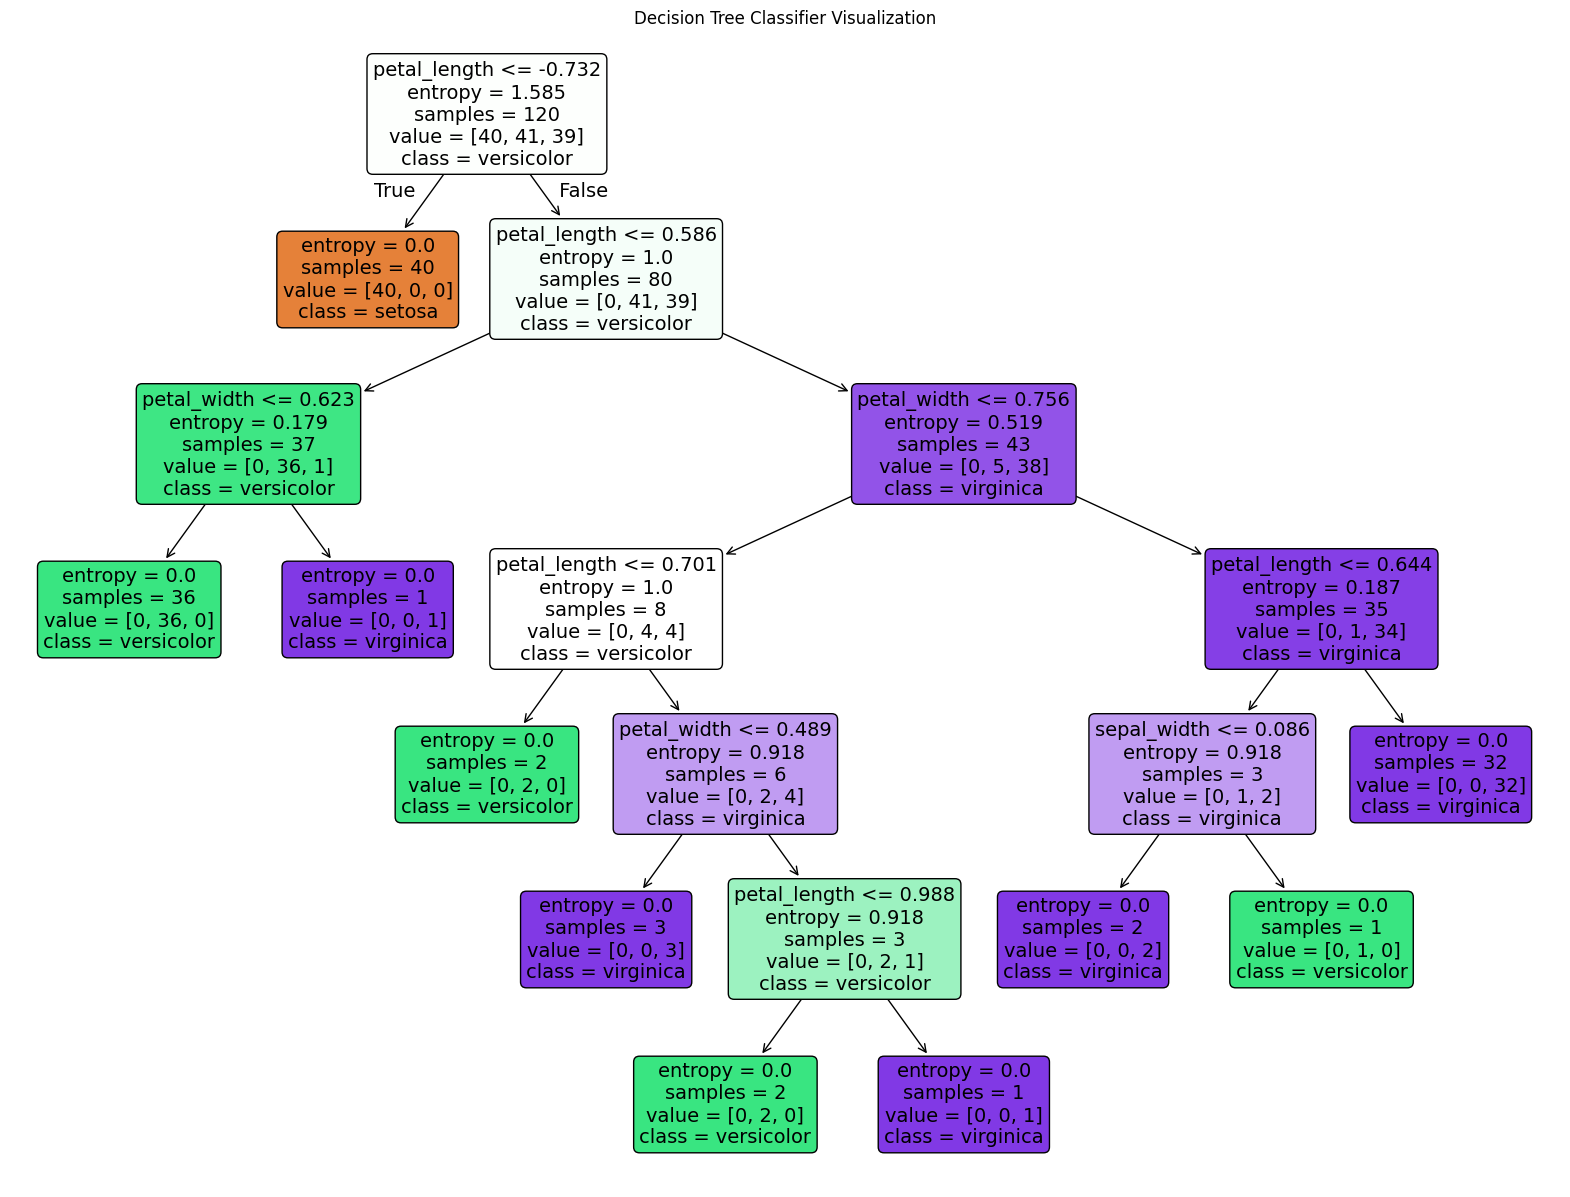

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,15))
plot_tree(dtree, filled=True, feature_names=X.columns, class_names=iris_data.target_names, rounded=True)
plt.title('Decision Tree Classifier Visualization')
plt.show()


In [19]:
print(f"Depth of the Decision Tree: {dtree.get_depth()}")

Depth of the Decision Tree: 6


In [20]:
feature_importances = dtree.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(importance_df)


Feature Importances:


,Feature,Importance
2,petal_length,0.895406
3,petal_width,0.090107
1,sepal_width,0.014487
0,sepal_length,0.000000


In [21]:
selected_features_0_05 = importance_df[importance_df['Importance'] > 0.05]['Feature'].tolist()

print(f"Features with importance > 0.05: {selected_features_0_05}")

Features with importance > 0.05: ['petal_length', 'petal_width']


In [22]:
X_train_scaled_filtered_0_05 = X_train_scaled[selected_features_0_05]
X_test_scaled_filtered_0_05 = X_test_scaled[selected_features_0_05]

print("Filtered X_train_scaled head (importance > 0.05):")
display(X_train_scaled_filtered_0_05.head())
print("\nFiltered X_test_scaled head (importance > 0.05):")
display(X_test_scaled_filtered_0_05.head())

Filtered X_train_scaled head (importance > 0.05):


,petal_length,petal_width
0,-1.562535,-1.312603
1,-1.276006,-1.045633
2,0.385858,0.289218
3,-1.218701,-1.312603
4,-1.390618,-1.312603



Filtered X_test_scaled head (importance > 0.05):


,petal_length,petal_width
0,0.557775,0.022248
1,-1.161395,-1.179118
2,1.818500,1.490583
3,0.443164,0.422703
4,0.615081,0.289218


In [23]:
dtree_filtered_0_05 = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtree_filtered_0_05.fit(X_train_scaled_filtered_0_05, y_train)

print("New DecisionTreeClassifier trained with filtered features (importance > 0.05):")
display(dtree_filtered_0_05)

New DecisionTreeClassifier trained with filtered features (importance > 0.05):


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [24]:
y_pred_filtered_0_05 = dtree_filtered_0_05.predict(X_test_scaled_filtered_0_05)

accuracy_filtered_0_05 = accuracy_score(y_test, y_pred_filtered_0_05)
conf_matrix_filtered_0_05 = confusion_matrix(y_test, y_pred_filtered_0_05)
class_report_filtered_0_05 = classification_report(y_test, y_pred_filtered_0_05)

print(f"Accuracy with filtered features (importance > 0.05): {accuracy_filtered_0_05:.4f}")
print("\nConfusion Matrix with filtered features (importance > 0.05):")
print(conf_matrix_filtered_0_05)
print("\nClassification Report with filtered features (importance > 0.05):")
print(class_report_filtered_0_05)

Accuracy with filtered features (importance > 0.05): 1.0000

Confusion Matrix with filtered features (importance > 0.05):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report with filtered features (importance > 0.05):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



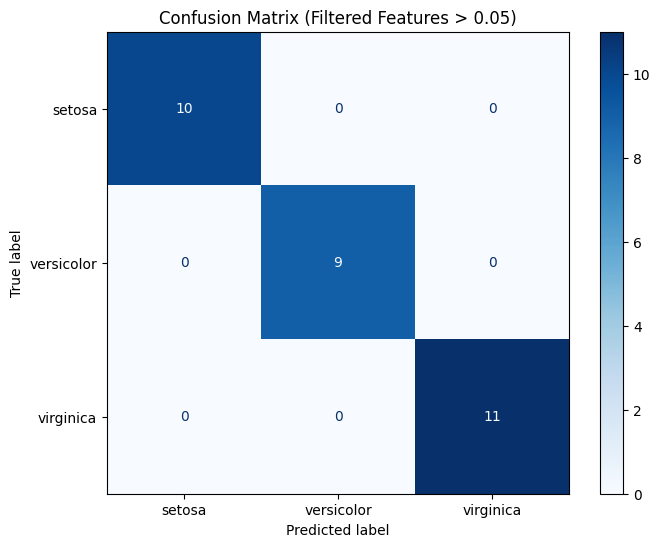

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot the confusion matrix for the filtered model
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    dtree_filtered_0_05,
    X_test_scaled_filtered_0_05,
    y_test,
    display_labels=iris_data.target_names,
    cmap=plt.cm.Blues,
    ax=ax
)
ax.set_title('Confusion Matrix (Filtered Features > 0.05)')
plt.show()

In [26]:
import pickle

# Define the filename for the pickled model
model_filename = 'dtree_filtered_0_05_model.pkl'

# Save the model to a file
with open(model_filename, 'wb') as file:
    pickle.dump(dtree_filtered_0_05, file)

print(f"Model successfully pickled and saved as '{model_filename}'")

Model successfully pickled and saved as 'dtree_filtered_0_05_model.pkl'
